<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# DS02_LAB02

## Guilherme Alfredo Kastner

## Objetivos

Use o Jupyter LDS_DecisionTree como base para aplicar a classificação em árvore para os dados neste link.

Explore diferentes valores para os parâmetros do método: 
- max_depth​, 
- min_samples_split​​, 
- min_samples_leaf​​

Entregue um Arquivo Jupyter com a árvore os parâmetros escolhidos e uma análise dos principais nós.

# Case de análise de massa corporal



### Análise de dados de massa de uma população

In [15]:
# check Python version
!python -V

import pandas as pd # download library to read data into dataframe
import numpy as np # import numpy library
import matplotlib.pyplot as plt # plots
import collections
import random # library for random number generation

Python 3.10.0


## Importar Arquivo de dados

Inclua um CSV com os dados a serem analisados
 * Incluindo cabeçalho
 * Separação de campos delimitado por *,*
 * Separação de linha usando *nova linha*

 O arquivo tem mais de 600 registros, pode levar alguns segundos.

In [16]:
print("Data read into dataframe!")

file_path = "H_M_carac.csv"

df = pd.read_csv(file_path)
df.head()

Data read into dataframe!


,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar,sexo
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757,Homem
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727,Homem
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206,Mulher
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248,Mulher
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130,Homem


## Começando a análise

### Importar as bibliotecas: 
* SKLEARN
* graphviz
* matplotlib


In [17]:
# import decision trees scikit-learn libraries

from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import os

import matplotlib.pyplot as plt

#!conda install python-graphviz --yes
import graphviz

# Definindo variável alvo
target = 'percentual_gordura'

# Adicione o caminho onde está o dot.exe
graphviz_path = r'C:\Program Files\Graphviz\bin'

# Adiciona ao PATH na execução atual do Python
os.environ["PATH"] += os.pathsep + graphviz_path

from sklearn.tree import export_graphviz

import itertools

## Separar o dataFrame em variáveis dependentes e independentes

In [18]:
# split the DataFrame
sexo = df[["sexo"]] # Só a coluna "stars"

# Definindo variáveis preditoras (tirando sexo e massa muscular)
dadosSaude = df.drop(columns=['sexo'])
#dadosSaude = df.drop(columns=['sexo', 'percentual_gordura'])

print(sexo.head())
dadosSaude.head()

     sexo
0   Homem
1   Homem
2  Mulher
3  Mulher
4   Homem


,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130


## Adequação das variáveis categóricas em colunas binárias - OneHotEncoder




In [19]:
#from sklearn.preprocessing import OneHotEncoder

cat = [i for i in sexo.columns if sexo[i].dtypes == "O"]

cat_one_hot_list = []
for i in cat:
    cat_one_hot_list.append(pd.get_dummies(sexo[[i]]))


# Concatenando as variáveis categóricas codificadas
cat_one_hot_df = pd.concat(cat_one_hot_list, axis=1)

# Juntando com os dados de saúde (numéricos)
X = pd.concat([dadosSaude, cat_one_hot_df], axis=1)

# retirada de sexo feminino, afinal ou é masculino ou feminino
X = X.drop(columns=['sexo_Mulher'])


X.head()

,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar,sexo_Homem
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757,True
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727,True
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206,False
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248,False
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130,True


## DecisionTreeClassifier e os seus Parâmetros

O algoritimo do DecisionTreeClassifier tem a tendência natural de fazer um OVERFITING, para ajustar isso modificamos os parâmetros:

* max_depth : Profundidade máxima da árvore
* min_samples_split : quantidade mínima de amostras para se dividir um nó
* min_samples_leaf : Quantidade mínima de amostras em um nó folha (nó da base da árvore)

In [20]:
# Criando e treinando a árvore
tree = DecisionTreeRegressor(max_depth = 3, min_samples_split = 40, min_samples_leaf = 10)
tree.fit(X, df[target])


print("Decision tree model saved to delivery_tree!")
print(tree)
print(X.columns.values)

Decision tree model saved to delivery_tree!
DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, min_samples_split=40)
['altura' 'peso' 'idade' 'massa_muscular' 'percentual_gordura'
 'tamanho_osseo' 'capacidade_pulmonar' 'sexo_Homem']


## Resultados em formato gráfico são sempre melhores &#x1F600;

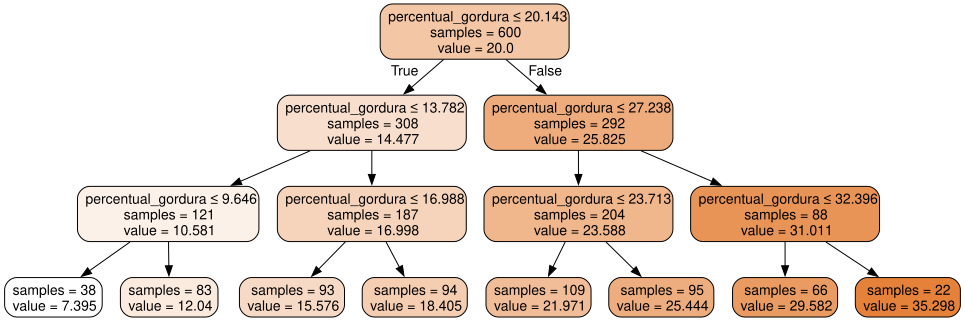

In [21]:
# Gerando o .dot em string
dot_data = export_graphviz(
    tree,
    feature_names=list(X.columns),
    class_names=[str(c) for c in np.unique(target)],
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=False,
    label="all"
)

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)

# Para visualização
graph

## *Modificar a variável dependente para (bad, average, good) ao invés de [1,5]*

Isso nos permitira encontrar mais facilmente as causas das viagens ruins

Atenção: na saída gráfica os valores do vetor Value estarão em ordem alfabeetica, ou seja, (average, bad, good)

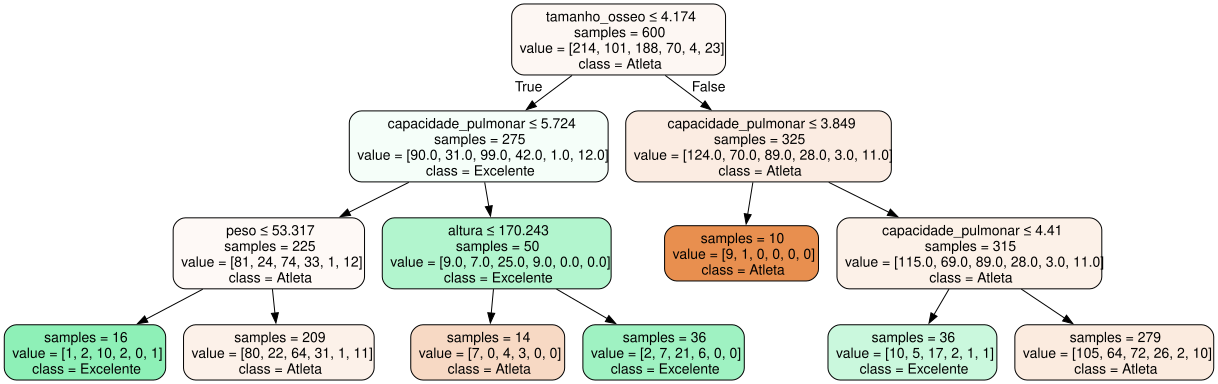

In [22]:
# Criando uma variável categórica para a classificação
gordura_class = pd.Series(index=X.index, dtype="object")

# Para Homens
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] <= 13)] = 'Atleta'
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] > 13) & (X['percentual_gordura'] <= 17)] = 'Excelente'
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] > 17) & (X['percentual_gordura'] <= 20)] = 'Bom'
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] > 20) & (X['percentual_gordura'] <= 24)] = 'Médio'
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] > 24) & (X['percentual_gordura'] <= 30)] = 'Ruim'
gordura_class.loc[(X['sexo_Homem'] == True) & (X['percentual_gordura'] > 30)] = 'Obesidade'

# Para Mulheres
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] <= 23)] = 'Atleta'
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] > 23) & (X['percentual_gordura'] <= 27)] = 'Excelente'
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] > 27) & (X['percentual_gordura'] <= 30)] = 'Bom'
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] > 30) & (X['percentual_gordura'] <= 34)] = 'Médio'
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] > 34) & (X['percentual_gordura'] <= 39)] = 'Ruim'
gordura_class.loc[(X['sexo_Homem'] == False) & (X['percentual_gordura'] > 39)] = 'Obesidade'

# 1. Concatenar a coluna gordura_class no dataframe X
X = pd.concat([X, gordura_class.rename('gordura_class')], axis=1)


# 2. Remover a coluna percentual_gordura
X = X.drop(columns=['percentual_gordura'])

# 3. Definir o target como a coluna gordura_class
target = [gordura_class]

# 4. Definir as features como todo o restante (removendo o target)
# Features sem a coluna alvo
dadosSaude = X.drop(columns=['gordura_class'])


# Target é a coluna gordura_class
target = X['gordura_class']

# Criando o modelo
tree = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=40, 
    min_samples_leaf=10
)

# Treinando o modelo
tree.fit(dadosSaude, target)

# Gerando o .dot em string
dot_data = export_graphviz(
    tree,
    feature_names=list(dadosSaude.columns),
    class_names=[str(c) for c in np.unique(target)],
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=False,
    label="all"
)

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)
graph

## Vamos retirar as mulheres e dados de tamanho osseo?

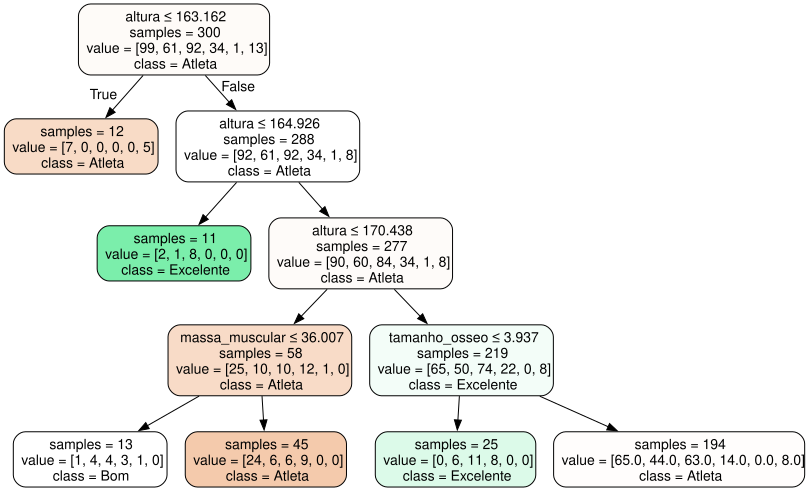

In [23]:
XHomem = X[X['sexo_Homem']]
dadosSaudeHomem = dadosSaude[dadosSaude['sexo_Homem']]
targetHomem = target[X['sexo_Homem']]

# print(dadosSaudeHomem.head())
# print(targetHomem.head())

tree = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_split=20, 
    min_samples_leaf=10
)

# Treinando o modelo
tree.fit(dadosSaudeHomem, targetHomem)

# Gerando o .dot em string
dot_data = export_graphviz(
    tree,
    feature_names=list(dadosSaudeHomem.columns),
    class_names=[str(c) for c in np.unique(targetHomem)],
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=False,
    label="all"
)

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)
graph

A árvore encontrou que a altura é o primeiro e principal critério que melhor separa os grupos de percentual de gordura.

Após a altura, outros critérios como massa muscular e tamanho ósseo ajudam a definir se uma pessoa está mais próxima de ser Atleta, Excelente, Bom, etc.

### Parece que estudar os dados de mulheres pode ser importante

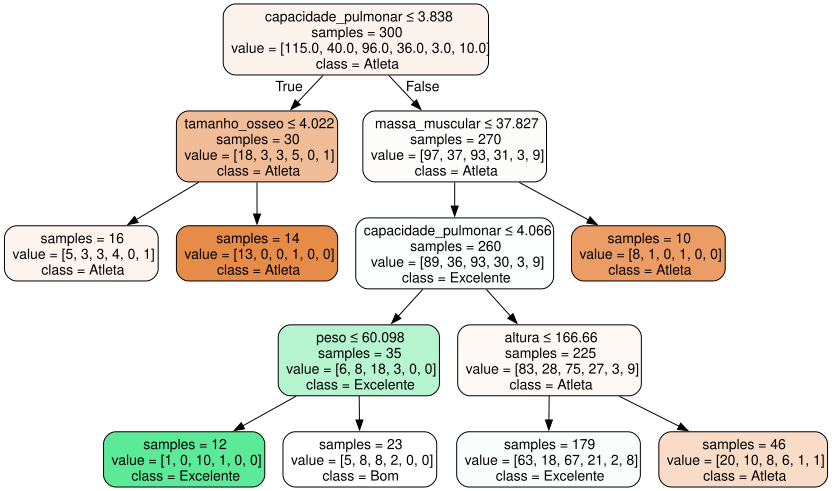

In [24]:
XMulher = X[X['sexo_Homem'] == False]
dadosSaudeMulher = dadosSaude[dadosSaude['sexo_Homem'] == False]
targetMulher = target[X['sexo_Homem'] == False]

# print(dadosSaudeMulher.head())
# print(targetMulher.head())

tree = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_split=20, 
    min_samples_leaf=10
)

# Treinando o modelo
tree.fit(dadosSaudeMulher, targetMulher)

# Gerando o .dot em string
dot_data = export_graphviz(
    tree,
    feature_names=list(dadosSaudeMulher.columns),
    class_names=[str(c) for c in np.unique(targetMulher)],
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=False,
    label="all"
)

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)
graph

- Divisão esquerda (capacidade_pulmonar ≤ 3.838):
Pessoas com baixa capacidade pulmonar.

Depois, subdivide pelo tamanho ósseo ≤ 4.022.

Continua mostrando que dentro dos que têm baixa capacidade pulmonar, o tamanho ósseo ajuda a discriminar subgrupos, mas ainda predomina a classe Atleta.

- Divisão direita (capacidade_pulmonar > 3.838):
Aqui estão pessoas com capacidade pulmonar mais alta.

A árvore subdivide em:

Primeiro, por massa muscular ≤ 37.827 (se não, vai direto para um grupo pequeno com 10 amostras).

Depois, nos que passam do primeiro filtro, subdivide por capacidade_pulmonar ≤ 4.066, refinando ainda mais.

A árvore continua refinando com divisões por peso ≤ 60.098 e depois por altura ≤ 166.66.

De acordo com esses parâmetros não apareceram mulheres com percentuais de gordura altos, com isso pode ser manipulado com os dados de expansão de árvore

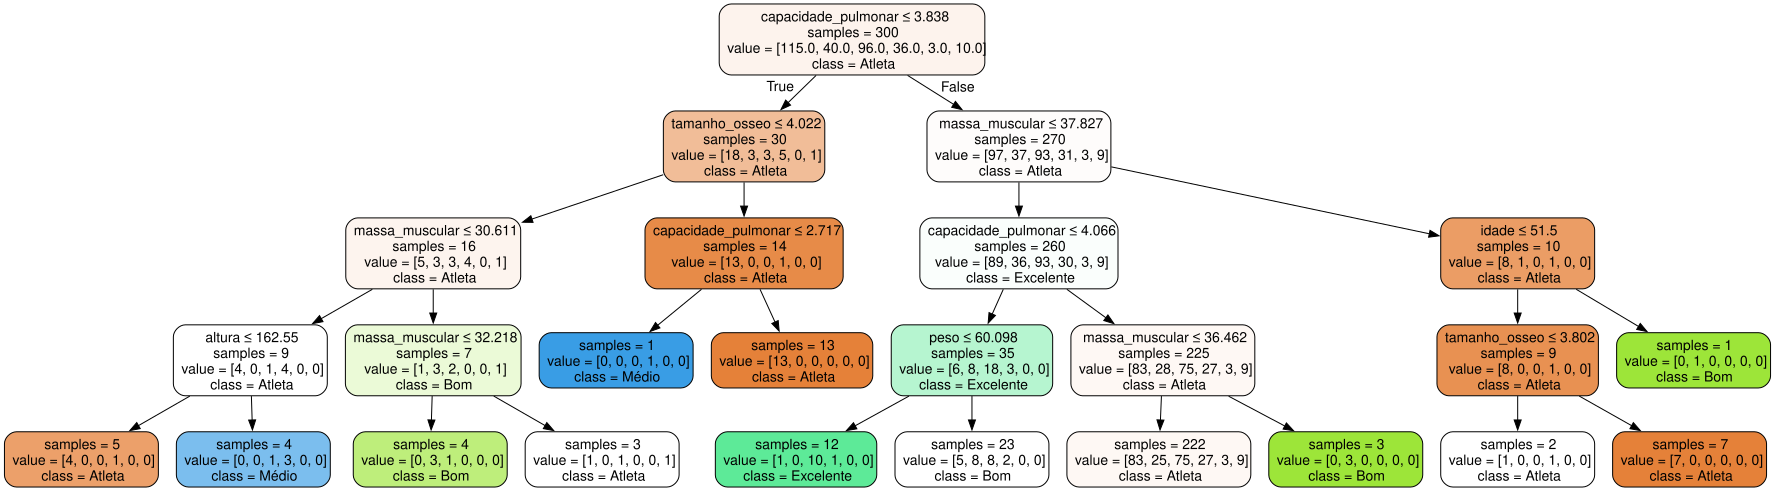

In [25]:
tree = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_split=2, 
    min_samples_leaf=1
)

# Treinando o modelo
tree.fit(dadosSaudeMulher, targetMulher)

# Gerando o .dot em string
dot_data = export_graphviz(
    tree,
    feature_names=list(dadosSaudeMulher.columns),
    class_names=[str(c) for c in np.unique(targetMulher)],
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=False,
    label="all"
)

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)
graph

A árvore agora cria mais ramificações, indo mais fundo na hierarquia das condições.

Isso significa que você reduziu os parâmetros como:

min_samples_split (divisões são feitas mesmo com menos amostras).

min_samples_leaf (permite folhas com menos amostras).

Ou aumentou max_depth.